<a href="https://colab.research.google.com/github/dainguyenbao2006-cyber/K_means/blob/main/choose_K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install cupy-cuda12x

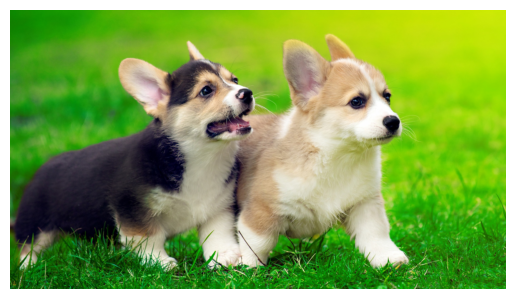

Image shape: (1080, 1920, 3)


In [ ]:
path = '/content/dog.jpg'
image = cv2.imread(path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()
print(f'Image shape: {image.shape}')

In [ ]:
resized_img = cv2.resize(image_rgb, (200, 200))
print(f'Resized image shape: {resized_img.shape}')

Resized image shape: (200, 200, 3)


In [ ]:
pixel_values = resized_img.reshape((-1, 3))
print(f'Pixel values shape: {pixel_values.shape}')

Pixel values shape: (40000, 3)


In [ ]:
pixel_values = np.float32(pixel_values)
print(f'Pixel values dtype: {pixel_values.dtype}')

Pixel values dtype: float32


In [ ]:
import cupy as cp

class KMeansGPU:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None

    def fit(self, X) :
        self.X = cp.array(X)
        self.n_samples, self.n_features = self.X.shape

        random_indices = cp.random.choice(self.n_samples, self.k, replace=False)
        self.centroids = self.X[random_indices]

        for i in range(self.max_iters):
            distances = cp.linalg.norm(self.X[:, cp.newaxis] - self.centroids, axis=2)
            labels = cp.argmin(distances, axis=1)

            centroids_old = self.centroids.copy()

            new_centroids = cp.array([self.X[labels == j].mean(axis=0) if cp.any(labels == j)
                                     else self.centroids[j] for j in range(self.k)])

            self.centroids = new_centroids

            if cp.all(centroids_old == self.centroids):
                break

        self.labels = labels

    def calculate_wcss(self):
        wcss = 0
        for j in range(self.k):
            points = self.X[self.labels == j]
            if len(points) > 0:
                wcss += cp.sum((points - self.centroids[j]) ** 2)
        return float(wcss)

    def _create_clusters(self, centroids):
        clusters = [[] for _ in range(self.k)]
        for idx, sample in enumerate(self.X):

            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx)
        return clusters

    def _closest_centroid(self, sample, centroids):

        distances = [np.sqrt(np.sum((sample - point)**2)) for point in centroids]
        return np.argmin(distances)

    def _get_centroids(self, clusters):
        centroids = np.zeros((self.k, self.n_features))
        for cluster_idx, cluster in enumerate(clusters):
            cluster_mean = np.mean(self.X[cluster], axis=0)
            centroids[cluster_idx] = cluster_mean
        return centroids

    def _is_converged(self, centroids_old, centroids_new):
        distances = [np.sqrt(np.sum((centroids_old[i] - centroids_new[i])**2)) for i in range(self.k)]
        return sum(distances) == 0

    def predict(self, X):

        labels = []
        for sample in X:
            labels.append(self._closest_centroid(sample, self.centroids))
        return np.array(labels)


Hoàn thành K=1
Hoàn thành K=2
Hoàn thành K=3
Hoàn thành K=4
Hoàn thành K=5
Hoàn thành K=6
Hoàn thành K=7
Hoàn thành K=8
Hoàn thành K=9


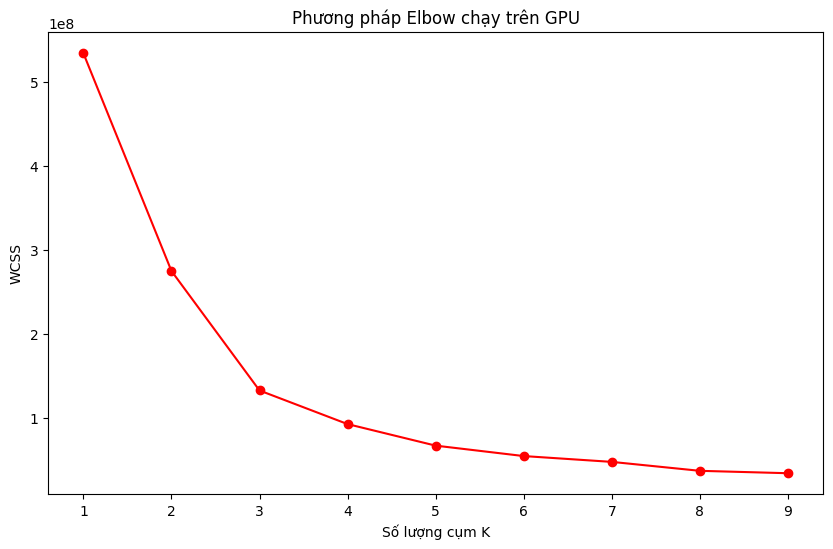

In [ ]:
import matplotlib.pyplot as plt

wcss_values = []
k_range = range(1, 10)

pixel_values_gpu = pixel_values.astype('float32')

for k in k_range:
    model_gpu = KMeansGPU(k=k, max_iters=20)
    model_gpu.fit(pixel_values_gpu)
    wcss_values.append(model_gpu.calculate_wcss())
    print(f"Hoàn thành K={k}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss_values, 'ro-')
plt.title('Phương pháp Elbow chạy trên GPU')
plt.xlabel('Số lượng cụm K')
plt.ylabel('WCSS')
plt.show()

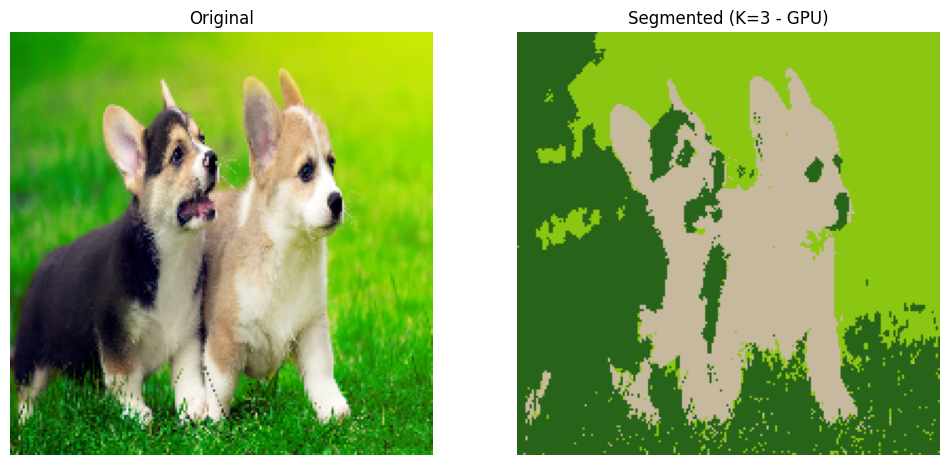

In [ ]:
import types

model = KMeansGPU(k=3)
model.fit(pixel_values)

def _corrected_predict_method(self, X):
    X_gpu = cp.array(X)
    distances = cp.linalg.norm(X_gpu[:, cp.newaxis] - self.centroids, axis=2)
    labels = cp.argmin(distances, axis=1)
    return labels


model.predict = types.MethodType(_corrected_predict_method, model)


labels_gpu = model.predict(cp.array(pixel_values))


centroids_cpu = cp.asnumpy(model.centroids)
labels_cpu = cp.asnumpy(labels_gpu)


segmented_data = centroids_cpu[labels_cpu]


segmented_image = segmented_data.reshape(resized_img.shape).astype(np.uint8)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(resized_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Segmented (K={model.k} - GPU)")
plt.imshow(segmented_image)
plt.axis('off')

plt.show()

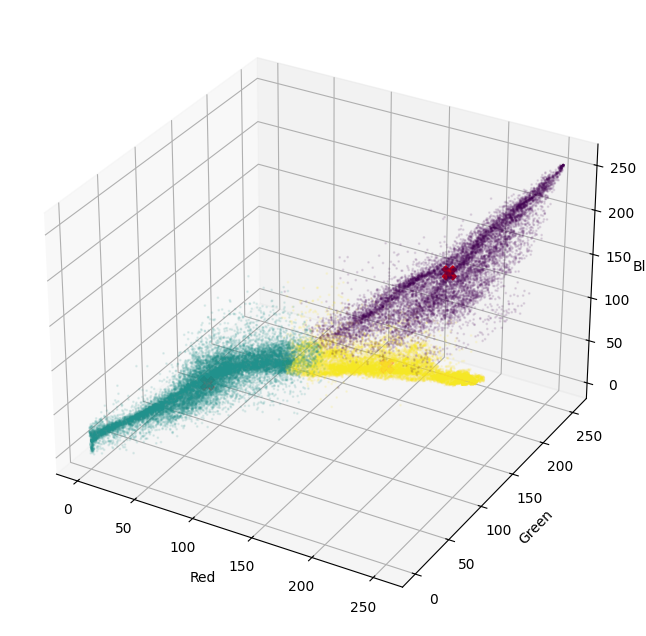

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pixels(X, labels=None, centroids=None):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X/255.0, s=1, alpha=0.1)
    else:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=1, alpha=0.1)

    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   c='red', s=100, marker='X', label='Centroids')

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    plt.show()

plot_pixels(pixel_values, labels=labels_cpu, centroids=model.centroids.get())

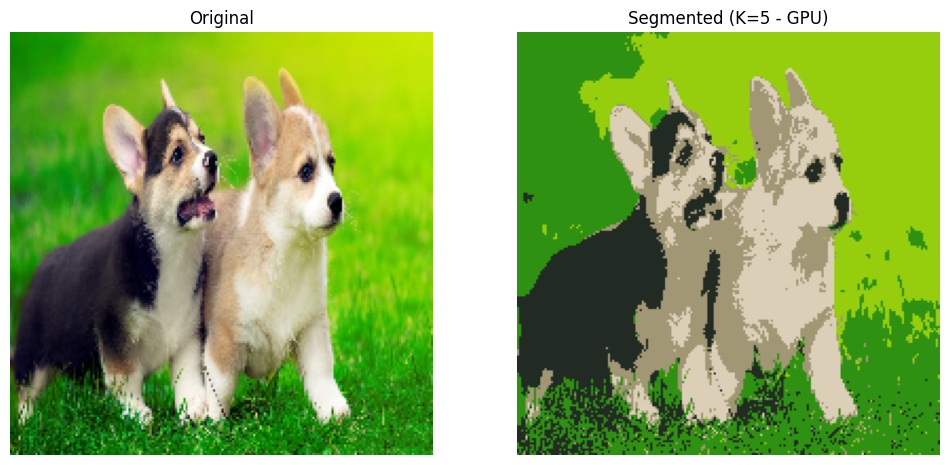

In [ ]:
import types

model = KMeansGPU(k=5)
model.fit(pixel_values)

def _corrected_predict_method(self, X):
    X_gpu = cp.array(X)
    distances = cp.linalg.norm(X_gpu[:, cp.newaxis] - self.centroids, axis=2)
    labels = cp.argmin(distances, axis=1)
    return labels

model.predict = types.MethodType(_corrected_predict_method, model)

labels_gpu = model.predict(cp.array(pixel_values))

centroids_cpu = cp.asnumpy(model.centroids)
labels_cpu = cp.asnumpy(labels_gpu)


segmented_data = centroids_cpu[labels_cpu]


segmented_image = segmented_data.reshape(resized_img.shape).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(resized_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Segmented (K={model.k} - GPU)")
plt.imshow(segmented_image)
plt.axis('off')

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

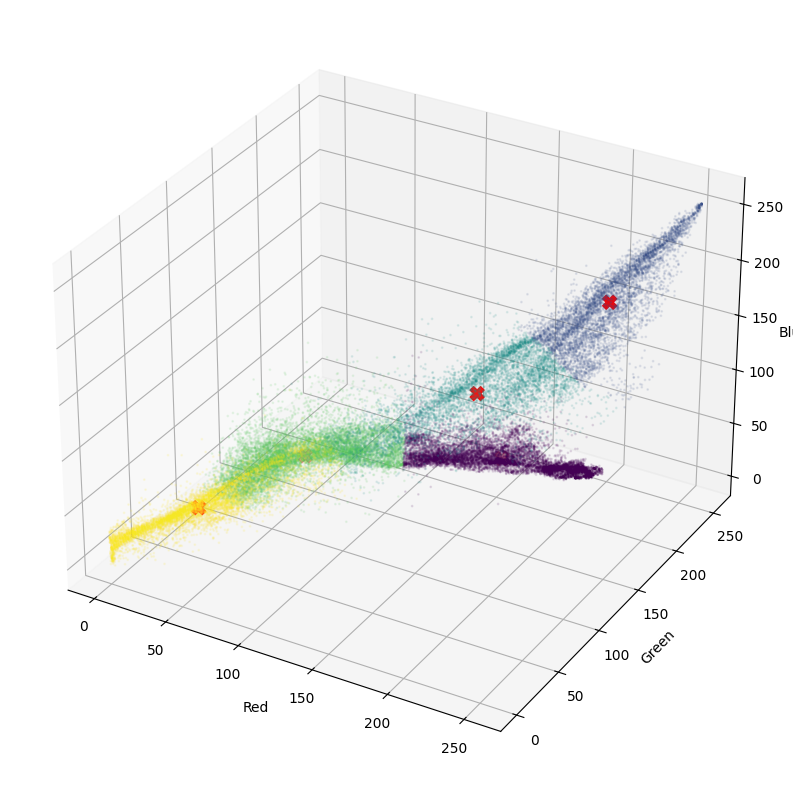

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pixels(X, labels=None, centroids=None):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X/255.0, s=1, alpha=0.1)
    else:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=1, alpha=0.1)

    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   c='red', s=100, marker='X', label='Centroids')

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    plt.show()

plot_pixels(pixel_values, labels=labels_cpu, centroids=model.centroids.get())

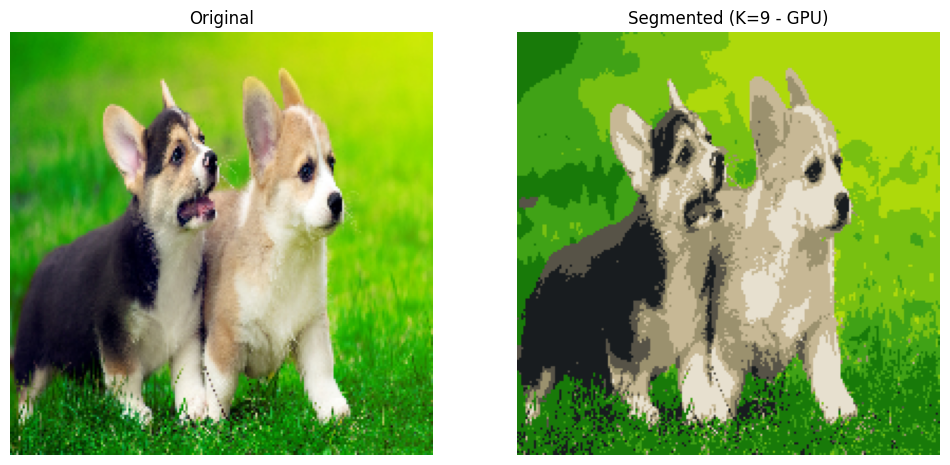

In [ ]:
import types

model = KMeansGPU(k=9)
model.fit(pixel_values)


def _corrected_predict_method(self, X):
    X_gpu = cp.array(X)

    distances = cp.linalg.norm(X_gpu[:, cp.newaxis] - self.centroids, axis=2)
    labels = cp.argmin(distances, axis=1)
    return labels


model.predict = types.MethodType(_corrected_predict_method, model)


labels_gpu = model.predict(cp.array(pixel_values))


centroids_cpu = cp.asnumpy(model.centroids)
labels_cpu = cp.asnumpy(labels_gpu)


segmented_data = centroids_cpu[labels_cpu]


segmented_image = segmented_data.reshape(resized_img.shape).astype(np.uint8)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(resized_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Segmented (K={model.k} - GPU)")
plt.imshow(segmented_image)
plt.axis('off')

plt.show()

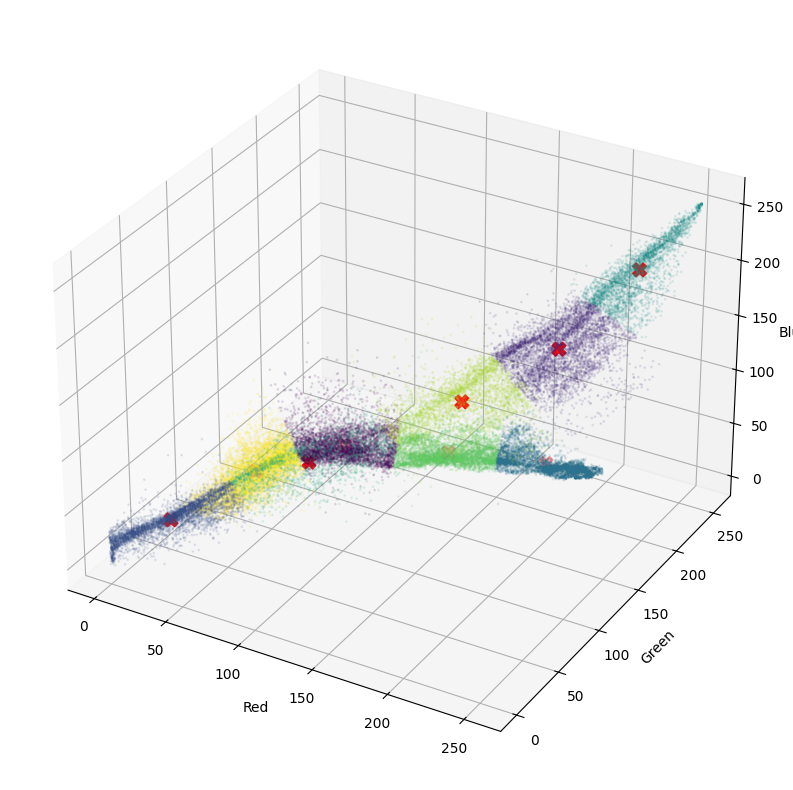

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pixels(X, labels=None, centroids=None):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X/255.0, s=1, alpha=0.1)
    else:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=1, alpha=0.1)

    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   c='red', s=100, marker='X', label='Centroids')

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    plt.show()

plot_pixels(pixel_values, labels=labels_cpu, centroids=model.centroids.get())